 # Graph Neural Networks
 
----

# Network Architecture

The basic computational unit of a neural network is an artificial "neuron", which takes an input value ($x$), multiplies it by a learned weight ($w$) and adds a bias term ($b$). A neural network is made up of layers of neurons each performing their own mathematical operations that are learned during the training process.  Single neurons follow an equation similar to simple linear regression: 
$$
y_k = x_1 w_{1k} + x_2 w_{2k} + \cdots + x_n w_{nk} + b_k
$$

In a fully connected layer, the input for each neuron is connected to the output from each neuron in the previous layer, allowing information to pass between layers. If a neural network was only made up of fully connect layers, it would only ever be able to solve linear problems. Non-linearity can be introduced using an *activation layers* like the Rectified Linear Unit (ReLU) layer:

$$
ReLU(x) = \max(x,0) = \begin{cases} x & \text{dla } x \geq 0,\\ 0 & \text{dla } x < 0. \end{cases}
$$

ReLU is commonly used in neural network architectures, but other activation functions are available.

# Loss Functions 
While the neural network architecture defines the mathematical operations that can be performed by the model, it does not describe the prediction task. We need to tell the network what to optimise by defining a *Loss Function*, something that the network must minimise by learning the appropriate model weights. 

For regression tasks, a common loss function is to minimise the mean square error with respect to the model parameters ($\Theta$): 
$$
\mathcal{L}(\mathcal{X}|\Theta)=\mathrm{MSE}(\mathcal{X}|\Theta) = \frac{1}{|\mathcal{X}|} \sum_{i=1}^{|\mathcal{X}|} (y_i - f(\mathbf{x}_i|\Theta))^2
$$ 

$$
\Theta^* = {\arg \min}_\Theta \,\, \mathcal{L}(\mathcal{X}|\Theta)
$$

----
# Intro to Pytorch

There are many python libraries built to help us build neural networks:
* Pytorch
* Tensorflow
* JAX

We will be using pytorch to construct a neural network for a regression problem.

To build our first neural network, we will need to use the following modules from pytorch:
* `torch.nn.Sequential # allows use to define an order of layers`
* `torch.nn.Linear # a linear, fully connected layer`
* `torch.nn.ReLU # activation layer`

Pytorch neural networks are defined as classes with feed forwards functions. See the implementation below of a very simple network designed to make regression predictions on SciKit-Learns diabetes dataset. Our model will take 10 features as the input (see first nn.Linear layer) and map to a latent space of 32 dimensions.  

In [25]:
from torch import nn

class SimpleNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential( # here we define our layers
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x) # the forward function is called during training. here, this just passes data through our defined layers

Now our network is defined, we can load an example dataset from SciKit-Learn

In [20]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()

x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

Pytorch uses Tensors as inputs to its neural networks. Tensors are simply multidimensional arrays, but we need to make sure we convert our data into tensor formats:

In [21]:
import torch

x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1) # make outputs have shape (n_samples, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

With SciKit-Learn, we could simply load our input features and output values by calling the .fit() function, but pytorch is a bit different. 

We need to tell Pytorch that we are using a dataset and put that dataset into a dataloader:

In [22]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


The last thing we need to define is our loss function

In [23]:
loss_function = nn.MSELoss() # loss fn


# Training Neural Networks
The training process for a neural network is different to models we have trained in previous labs.

Instead of passing our data through the model once to determine a fit, a neural network will see our training data many times. Each time we pass our data through the model (known as an epoch), we calculate an output value based on our inputs (this is essentially making a prediction), then we calculate the loss to find out how bad that prediction was. The next step is called *back propagation* and is one of the key steps in training a neural network. The model calculates how much each weight contributed to the loss using differential equations and updates those weights accordingly. Then, the data is passed through the model again to test the newly updated weights. 

The training process for a neural network is as follows:
1. Pass inputs into the network
2. Calculate an output based on model weights
3. Calculate the loss
4. Backpropagate the errors
5. Repeat

Below we will train our model for 100 epochs:

In [34]:
epochs = 100
losses = []

model = SimpleNeuralNetwork()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001) # lr is the Learning Rate

# define our training loop
for epoch in range(epochs): 
    epoch_loss = 0
    model.train() # set model to train configuration
    
    for x_batch, y_batch in train_loader: # train loaders organise data into batches
        preds = model(x_batch) # forward pass of data
        
        loss = loss_function(preds, y_batch) # calculate the loss
        epoch_loss += loss.item()
        
        optimiser.zero_grad() # clear old gradients
        
        loss.backward() # calculate new gradients
        optimiser.step()
        
        
    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}: Loss = {epoch_loss:.2f}") # print loss every 10 epochs

Epoch 10: Loss = 0.85
Epoch 20: Loss = 0.73
Epoch 30: Loss = 0.64
Epoch 40: Loss = 0.59
Epoch 50: Loss = 0.53
Epoch 60: Loss = 0.48
Epoch 70: Loss = 0.47
Epoch 80: Loss = 0.48
Epoch 90: Loss = 0.48
Epoch 100: Loss = 0.46


Now lets plot our loss. Generally, a neural network has finished training when the loss plateaus. Based on this plot, has your model finished training? How does it change when we increase/decrease the number of epochs? 

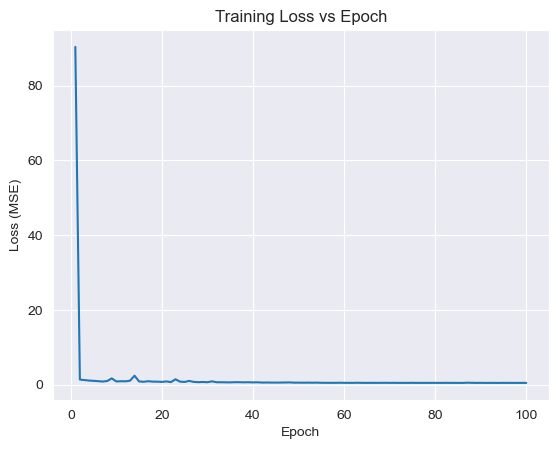

In [35]:
import matplotlib.pyplot as plt

plt.plot(range(1, epochs + 1), losses)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss vs Epoch")

plt.show()

# Graph Neural Networks for Chemistry

In matheamatics 